# MLP feedforward

In [1]:
# === Cell 0: imports & config ===

import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from scripts import style
style.mpl_apply()

# Reproducibility ------------------------------------------------------------
SEED = 246
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# If you have GPU, it will use it automatically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load the data

In [2]:
# === Cell 1: load data ===

# Adjust path if needed
DATA_PATH = Path("09 features/redes_local/datos/processed/df.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (200, 57)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,102.20103,105.277170,106.873116,32.077003,33.305286,33.510914,0.0,0.0,0.0,186.0,...,0.195138,-1419.565426,1.198618,1.749636,0.486834,-0.154286,Alfred_Sisley_1.jpg,Alfred_Sisley,Impresionismo,4
1,123.62030,136.959850,149.195050,46.771084,43.979904,49.263435,0.0,0.0,0.0,255.0,...,0.098290,-1419.565426,1.061136,0.937835,0.502996,-0.188640,Alfred_Sisley_10.jpg,Alfred_Sisley,Impresionismo,4
2,118.90262,116.895996,108.091415,48.649280,52.237015,61.140570,0.0,0.0,0.0,255.0,...,0.117654,-1419.489874,0.852622,1.311007,0.504956,-0.304950,Alfred_Sisley_11.jpg,Alfred_Sisley,Impresionismo,4
3,133.78065,140.773590,146.314380,36.072636,36.483162,50.136950,4.0,4.0,0.0,255.0,...,0.018207,-1419.565426,1.091522,1.702214,0.500399,-0.215292,Alfred_Sisley_12.jpg,Alfred_Sisley,Impresionismo,4
4,107.30281,108.520706,92.723560,32.748276,32.094944,37.935650,0.0,0.0,0.0,229.0,...,0.020639,-1419.565426,1.132043,2.128325,0.506062,-0.137083,Alfred_Sisley_13.jpg,Alfred_Sisley,Impresionismo,4


In [3]:
# print unique labels
print("Unique labels:", df["label"].unique())

Unique labels: [4 3 2 0 1]


In [4]:
# === Cell 2: build X, y ===

# Non-feature columns
meta_cols = ["filename", "painter", "genre", "label"]

# Feature columns = everything except meta
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].to_numpy(dtype=np.float32)   # (n_samples, n_features)
y = df["label"].to_numpy(dtype=np.int64)          # (n_samples,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", np.bincount(y))
print("Feature count:", len(feature_cols))


X shape: (200, 53)
y shape: (200,)
Class counts: [50 30 15 30 75]
Feature count: 53


In [5]:
# === Cell 3: class names for plots ===

class_names = [
    "Surrealismo",
    "Cubismo",
    "Expresionismo abstracto",
    "Barroco",
    "Impresionismo",
]
NUM_CLASSES = len(class_names)


# Train test

In [6]:
# === Cell 4: train/val/test split ===

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,           # 0.25 * 0.8 = 0.2 of total -> 60/20/20
    stratify=y_train_full,
    random_state=SEED,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (120, 53) (120,)
Val  : (40, 53) (40,)
Test : (40, 53) (40,)


In [7]:
# === Cell 5: scaling (fit on train only) ===

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled[:3]


array([[-0.99168324, -1.0093546 , -0.6653667 ,  1.213141  ,  0.68291706,
         0.0731273 , -0.21997513, -0.39128488, -0.29031417,  0.38166752,
         0.64260006,  0.71018845, -0.9199169 , -0.68152183, -1.1631025 ,
         1.2052071 ,  0.8737341 , -0.5878608 , -0.14312267, -0.01708209,
        -0.66350955, -0.4682503 , -1.0330325 ,  0.27204934, -1.019038  ,
         0.89327717, -1.1202941 , -0.08323518, -1.021269  ,  0.8344963 ,
        -0.7519607 , -0.42767635, -1.4894003 , -1.1726328 , -1.4123087 ,
        -0.7430112 ,  0.06238515,  2.1908584 , -1.6210308 , -0.8219374 ,
        -1.1528773 ,  0.07218459,  0.23150787,  1.7370213 , -0.56632316,
         0.11362287, -0.695935  , -0.0130108 ,  0.13699509, -1.1281079 ,
        -0.8237075 , -1.6494434 , -0.4123346 ],
       [ 1.5403649 ,  1.7590777 ,  2.1347964 , -0.61552113, -0.55163634,
        -0.14466004, -0.46591005, -0.39128488, -0.29031417,  0.38166752,
         0.64260006,  0.71018845, -1.8553367 , -1.8832456 ,  1.388039  ,
   

In [8]:
# === Cell 5: scaling (fit on train only) ===

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled[:3]


array([[-0.99168324, -1.0093546 , -0.6653667 ,  1.213141  ,  0.68291706,
         0.0731273 , -0.21997513, -0.39128488, -0.29031417,  0.38166752,
         0.64260006,  0.71018845, -0.9199169 , -0.68152183, -1.1631025 ,
         1.2052071 ,  0.8737341 , -0.5878608 , -0.14312267, -0.01708209,
        -0.66350955, -0.4682503 , -1.0330325 ,  0.27204934, -1.019038  ,
         0.89327717, -1.1202941 , -0.08323518, -1.021269  ,  0.8344963 ,
        -0.7519607 , -0.42767635, -1.4894003 , -1.1726328 , -1.4123087 ,
        -0.7430112 ,  0.06238515,  2.1908584 , -1.6210308 , -0.8219374 ,
        -1.1528773 ,  0.07218459,  0.23150787,  1.7370213 , -0.56632316,
         0.11362287, -0.695935  , -0.0130108 ,  0.13699509, -1.1281079 ,
        -0.8237075 , -1.6494434 , -0.4123346 ],
       [ 1.5403649 ,  1.7590777 ,  2.1347964 , -0.61552113, -0.55163634,
        -0.14466004, -0.46591005, -0.39128488, -0.29031417,  0.38166752,
         0.64260006,  0.71018845, -1.8553367 , -1.8832456 ,  1.388039  ,
   

# PyTorch

In [9]:
# === Cell 6: tensors & dataloaders ===

BATCH_SIZE = 32

X_train_t = torch.from_numpy(X_train_scaled).float()
y_train_t = torch.from_numpy(y_train).long()

X_val_t   = torch.from_numpy(X_val_scaled).float()
y_val_t   = torch.from_numpy(y_val).long()

X_test_t  = torch.from_numpy(X_test_scaled).float()
y_test_t  = torch.from_numpy(y_test).long()

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader), len(test_loader)


(4, 2, 2)

In [10]:
# === Cell 7: MLP definition ===

class MLPClassifierTorch(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), num_classes: int = NUM_CLASSES, dropout_p: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


input_dim = X_train.shape[1]
model = MLPClassifierTorch(input_dim=input_dim, hidden_dims=(64, 32), num_classes=NUM_CLASSES, dropout_p=0.3)
model.to(device)
model


MLPClassifierTorch(
  (net): Sequential(
    (0): Linear(in_features=53, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=5, bias=True)
  )
)

# Training

In [11]:
# === Cell 8: helpers for train & eval ===

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


In [12]:
# === Cell 9: training loop ===

EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader,   criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"- train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} "
        f"- val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f}"
    )

# Load best model (based on val accuracy)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Epoch 01/200 - train_loss: 1.5585, train_acc: 0.342 - val_loss: 1.5455, val_acc: 0.450
Epoch 02/200 - train_loss: 1.5176, train_acc: 0.392 - val_loss: 1.5116, val_acc: 0.500
Epoch 03/200 - train_loss: 1.4677, train_acc: 0.483 - val_loss: 1.4777, val_acc: 0.525
Epoch 04/200 - train_loss: 1.4403, train_acc: 0.475 - val_loss: 1.4409, val_acc: 0.575
Epoch 05/200 - train_loss: 1.4057, train_acc: 0.533 - val_loss: 1.4033, val_acc: 0.575
Epoch 06/200 - train_loss: 1.3637, train_acc: 0.492 - val_loss: 1.3657, val_acc: 0.575
Epoch 07/200 - train_loss: 1.3162, train_acc: 0.533 - val_loss: 1.3273, val_acc: 0.575
Epoch 08/200 - train_loss: 1.2810, train_acc: 0.592 - val_loss: 1.2913, val_acc: 0.575
Epoch 09/200 - train_loss: 1.2417, train_acc: 0.533 - val_loss: 1.2603, val_acc: 0.575
Epoch 10/200 - train_loss: 1.2049, train_acc: 0.533 - val_loss: 1.2324, val_acc: 0.575
Epoch 11/200 - train_loss: 1.1974, train_acc: 0.525 - val_loss: 1.2080, val_acc: 0.575
Epoch 12/200 - train_loss: 1.1224, train_ac

# Visualization

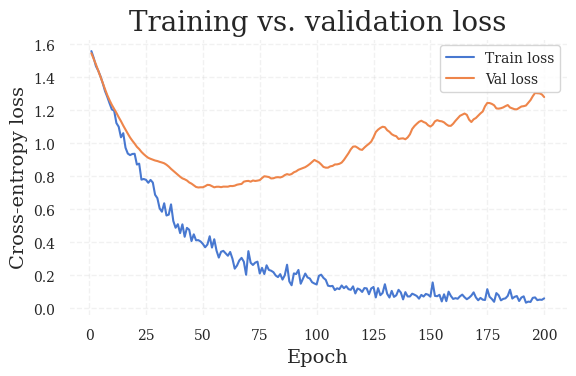

In [13]:
# === Cell 10: loss curves ===

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training vs. validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


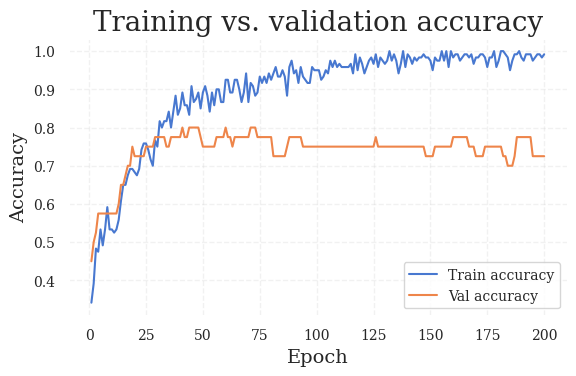

In [14]:
# === Cell 11: accuracy curves ===

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train accuracy")
plt.plot(epochs, history["val_acc"],   label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. validation accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# === Cell 12: test evaluation ===

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_logits = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        all_logits.append(logits.cpu())
        all_labels.append(y_batch)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    preds = all_logits.argmax(dim=1)
    return all_labels.numpy(), preds.numpy()


y_test_true, y_test_pred = predict_loader(model, test_loader, device)

test_acc = accuracy_score(y_test_true, y_test_pred)
print(f"Test accuracy: {test_acc:.3f}")

print("\nClassification report (test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names, digits=3))


Test accuracy: 0.775

Classification report (test):
                         precision    recall  f1-score   support

            Surrealismo      0.700     0.700     0.700        10
                Cubismo      1.000     0.167     0.286         6
Expresionismo abstracto      1.000     1.000     1.000         3
                Barroco      0.600     1.000     0.750         6
          Impresionismo      0.875     0.933     0.903        15

               accuracy                          0.775        40
              macro avg      0.835     0.760     0.728        40
           weighted avg      0.818     0.775     0.744        40



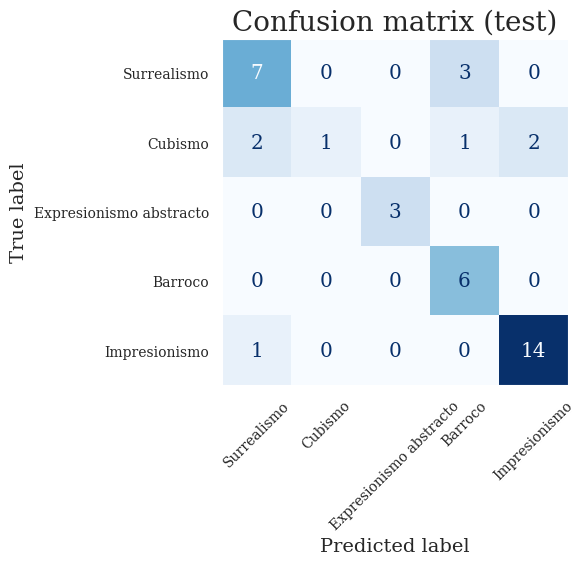

In [16]:
# === Cell 13: confusion matrix ===

cm = confusion_matrix(y_test_true, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.grid(False)
plt.show()


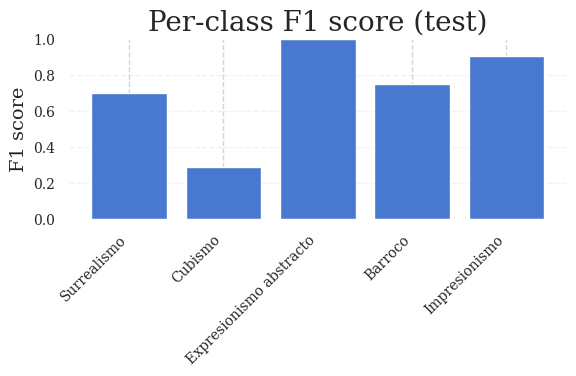

Surrealismo              : F1 = 0.700
Cubismo                  : F1 = 0.286
Expresionismo abstracto  : F1 = 1.000
Barroco                  : F1 = 0.750
Impresionismo            : F1 = 0.903


In [17]:
# === Cell 14: per-class F1 bar plot ===

f1_per_class = f1_score(
    y_test_true,
    y_test_pred,
    average=None,
    labels=np.arange(NUM_CLASSES),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_CLASSES), f1_per_class)
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-class F1 score (test)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1 in zip(class_names, f1_per_class):
    print(f"{name:25s}: F1 = {f1:.3f}")
